# Description
Look at the frozen season length as a function of $T_\text{w}$. (Note that the name of this notebook is outdated, but kept as is for consistency with personal notes; PN)

# Load analysis functions

In [1]:
%run ...../imports.ipynb
%run ...../snotelAnalysisFunctions.ipynb

# Additional functions

In [3]:
def E_tauF_normalDistDaily(amp,s,annualMeanTempRange=np.arange(-30,31,1)):
    '''
    Expected value of \tau_F when assuming a cosine temperature cycle with Gaussian daily-mean temperature noise with standard deviation s.
    '''
    omega = 2*np.pi/365
    time = np.arange(0,365)
    
    E_tauFs_theory = np.array([])

    for T in (annualMeanTempRange):
            cosineTemp = T-amp*np.cos(omega*time)
            if s!=0:
                expTauFTheory = np.sum(scipy.stats.norm(loc=cosineTemp,scale=s).cdf(0))
            elif s==0:
                expTauFTheory = numberOfFreezingDays(cosineTemp)
            E_tauFs_theory = np.append(E_tauFs_theory,expTauFTheory)
        
    return E_tauFs_theory

# Load data

add choice for loading all stations or just biased corrected stations...

In [5]:
stationBiasDict = loadTempBiasMarker()

In [6]:
rootPath = '/nfs/twcroninlab002/nicknish/snowpackProject/snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [7]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|███████████████████████████████████████████| 13/13 [00:15<00:00,  1.17s/it]


In [8]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Compute metrics

In [12]:
# Climatological seasonal temperature cycle at every station
meanTempWYs = np.zeros((numberStations,365))

# standard deviation of daily-mean temperatures in winter at each station
stationWinterDailySTD = np.array([])

# Station Names, states
stationNamesStates = []

In [13]:
for iState,stateName in enumerate(stateNames):
    currStateData = allStateDict_filtered[stateName]
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        stationNamesStates = stationNamesStates + [currStation.name + ' ' + stateName]

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [14]:
currStatInd = 0
for iState,stateName in enumerate(stateNames):
    currStateData = allStateDict_filtered[stateName]
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        currStationWYs = np.unique(currStation.water_year.values)
        stationTempWYs = np.zeros((len(currStationWYs),365))
        currAnnualMeanTemps = np.zeros(len(currStationWYs))
        for iWY,WY in enumerate(currStationWYs):
            currWY = currStation.sel(time=(currStation.water_year == WY))
            currT = currWY.T_avg
            # remove any obviously erroneous temperature values (i.e. way to warm)
            currT[currT>40] = np.nan
            currTInterp = fillNANTemp(currT.values)
            currTime = currWY.time
            winterInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)
            currWinterTemps = currTInterp[winterInds]
            meanWinterTemp = np.nanmean(currWinterTemps)
            if len(currTInterp)>365:
                currTInterp = currTInterp[:-1]
                
            stationTempWYs[iWY,:] = currTInterp
            currAnnualMeanTemps[iWY] = np.mean(currTInterp)

        stationMeanTempCycle = np.mean(stationTempWYs,0)
        meanTempWYs[currStatInd,:] = stationMeanTempCycle
        currStatInd = currStatInd + 1

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [15]:
## Compute standard deviation around daily mean temperature in the winter ##

currStatInd = 0
for iState,stateName in enumerate(stateNames):
    currStateData = allStateDict_filtered[stateName]
    for iS,currStation in (enumerate(currStateData)):
        print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
        currStationWYs = np.unique(currStation.water_year.values)
        winterTPrimes = np.array([])
        for iWY,WY in enumerate(currStationWYs):
            currWY = currStation.sel(time=(currStation.water_year == WY))
            currT = currWY.T_avg
            # remove any obviously erroneous temperature values (i.e. way to warm)
            currT[currT>40] = np.nan
            currTInterp = fillNANTemp(currT.values)
            currTime = currWY.time
            winterInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)
            if len(currTInterp)>365:
                currTInterp = currTInterp[:-1]
                winterInds = winterInds[:-1]
            currWinterTemps = currTInterp[winterInds]
            
            winterTPrimes = np.append(winterTPrimes,currWinterTemps-meanTempWYs[currStatInd,:][winterInds])
            
            currTPrimes = currWinterTemps-meanTempWYs[currStatInd,:][winterInds]
            
        stationWinterDailySTD = np.append(stationWinterDailySTD,np.std(winterTPrimes))
        currStatInd += 1

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

## Station and water year amplitudes

In [16]:
# for every station, get amplitude estimate from climatology
# this cell sets T1 = sqrt{\bar{T'^2}*2}
stationApproxAmpsSin = np.array([])
for i in range(numberStations):
    currWY = meanTempWYs[i,:]
    currTPrime = currWY-np.mean(currWY)
    
    amp = np.sqrt(np.mean(currTPrime**2)*2)
    stationApproxAmpsSin = np.append(stationApproxAmpsSin,amp)

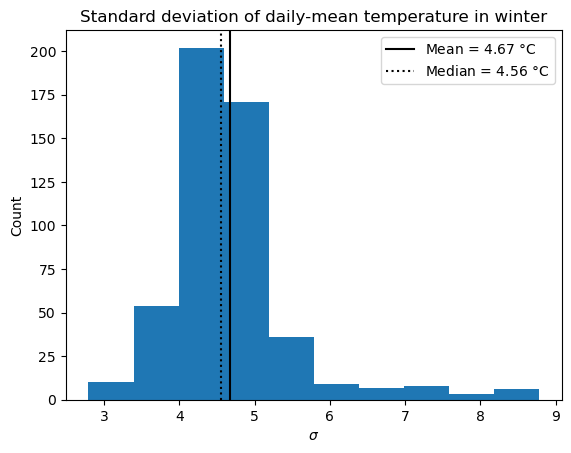

In [25]:
## A look at the station winter standard deviations in temperature

plt.hist(stationWinterDailySTD)
plt.title('Standard deviation of daily-mean temperature in winter')
plt.xlabel(r'$\sigma$')
plt.ylabel('Count')
plt.axvline(np.mean(stationWinterDailySTD),c='k',label=f'Mean = {round(np.mean(stationWinterDailySTD),2)} $\degree$C')
plt.axvline(np.median(stationWinterDailySTD),c='k',linestyle=':',label=f'Median = {round(np.median(stationWinterDailySTD),2)} $\degree$C')
plt.legend()

Text(0.5, 1.0, 'Station seasonal cycle amplitude from climatology')

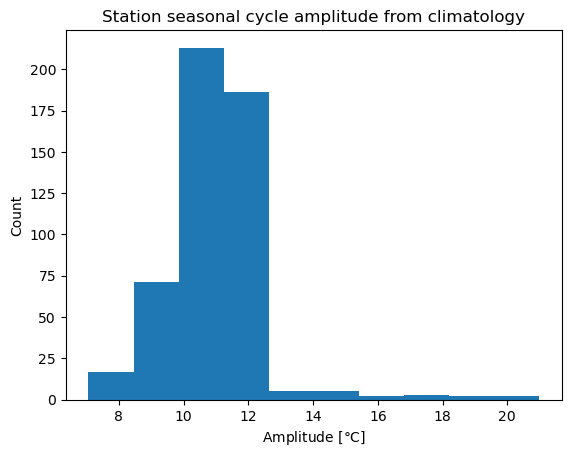

In [26]:
fig = plt.figure()
ax0 = plt.subplot(1,1,1)
ax0.hist(stationApproxAmpsSin)
ax0.set_ylabel('Count')
ax0.set_xlabel(r'Amplitude [$\degree$C]')
ax0.set_title('Station seasonal cycle amplitude from climatology')

## Plot amplitude vs standard deviation

Code for determining best fit line using orthogonal distance regression (as a compromise because is it not clear what the independent and dependent variables should be.

In [20]:
xAxisData = stationApproxAmpsSin
yAxisData = stationWinterDailySTD

In [21]:
def f(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]
linear = odr.Model(f)
mydata = odr.Data(xAxisData,yAxisData)
myodr = odr.ODR(mydata, linear, beta0=[1., 2.])
odrParams = myodr.run()

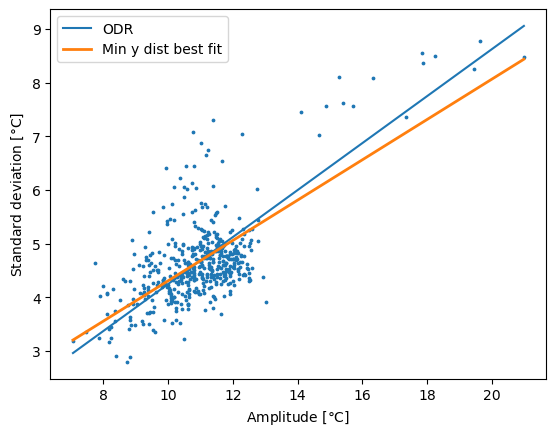

In [22]:
### Scatter the data ###
plt.scatter(xAxisData,yAxisData,3)

### Plot best fit curves ###
bestFitDomain = np.linspace(min(xAxisData),max(xAxisData),100)
## Plot the ODR best fit ##
odrBestFitFunction = np.poly1d(odrParams.beta)
plt.plot(bestFitDomain,odrBestFitFunction(bestFitDomain),label='ODR')
## Plot minimizing y-distance fit ##
fitDegree = 1
bestFitFunction = np.poly1d(np.polyfit(xAxisData,yAxisData,fitDegree))
bestFitLine = bestFitFunction(bestFitDomain)
plt.plot(bestFitDomain,bestFitLine,linewidth=2,label='Min y dist best fit')

plt.legend()
plt.ylabel(r'Standard deviation [$\degree$C]');
plt.xlabel(r'Amplitude [$\degree$C]');

In [23]:
## Save it here for plotting for supplemental figure
saveBool = False
if saveBool:
    pathToSave = '....../figureData'
    np.savez(pathToSave + '/figureSupp_sigmaT1.npz',
             stationApproxAmpsSin=stationApproxAmpsSin,
             stationWinterDailySTD=stationWinterDailySTD)

# Code for paper figure

## Sensitivity

In [34]:
Tw_adjs = np.arange(0,9,1)

adjTauFList = []
TwList = []

for adj in Tw_adjs:
    all_E_TauF_ForThisAdj = np.array([])
    allTw_ForThisAdj = np.array([])
    dlogTauF_dTw = np.array([])
    dlogTauF_dT0overT1 = np.array([])
    
    for iState,stateName in enumerate(stateNames):
        currStateData = allStateDict_filtered[stateName]
        for iS,currStation in (enumerate(currStateData)):
            print(f'{stateNames[:iState+1]}: {iS}/{len(currStateData)}         ', end="\r")
            currStationWYs = np.unique(currStation.water_year.values)
            currTauFs = np.array([])
            currT0s = np.array([])
            currT1s = np.array([])
            currTws = np.array([])
            stationTempWYs = np.zeros((len(currStationWYs),365))
            for iWY,WY in enumerate(currStationWYs):
                currWY = currStation.sel(time=(currStation.water_year == WY))
                currT = currWY.T_avg
                # remove any obviously erroneous temperature values (i.e. way to warm)
                currT[currT>40] = np.nan
                currTInterp = fillNANTemp(currT.values)
                currTime = currWY.time
                winterInds = np.logical_or(currTime.dt.month >= 11,currTime.dt.month <= 3)
                currWinterTemps = currTInterp[winterInds] + adj
                
                if len(currTInterp)>365:
                    currTInterp = currTInterp[:-1]
                
                stationTempWYs[iWY,:] = currTInterp
                
                adjustedTemperature = currTInterp + adj
                
                wyTPrime = adjustedTemperature-np.mean(adjustedTemperature)
                T1 = np.sqrt(np.mean(wyTPrime**2)*2)
                
                meanWinterTemp = np.nanmean(currWinterTemps)
                
                currTauFs = np.append(currTauFs,numberOfFreezingDays(adjustedTemperature))
                currTws = np.append(currTws,meanWinterTemp)
            
            all_E_TauF_ForThisAdj = np.append(all_E_TauF_ForThisAdj,np.mean(currTauFs))
            allTw_ForThisAdj = np.append(allTw_ForThisAdj,np.mean(currTws))
                        
    adjTauFList = adjTauFList + [all_E_TauF_ForThisAdj]
    TwList = TwList + [allTw_ForThisAdj]

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

In [35]:
# calcuate expected value of tauF at each warming level, then differentiate with respect to warming

adjTauFArray = np.array(adjTauFList)
TwArray = np.array(TwList)

tauFSenList_EtauF = np.gradient(np.log(adjTauFArray),axis=0)/np.gradient(TwArray,axis=0)

/tmp/ipykernel_26962/3763663591.py:18: RuntimeWarning: invalid value encountered in arccos
  tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,12.5)/12.5)


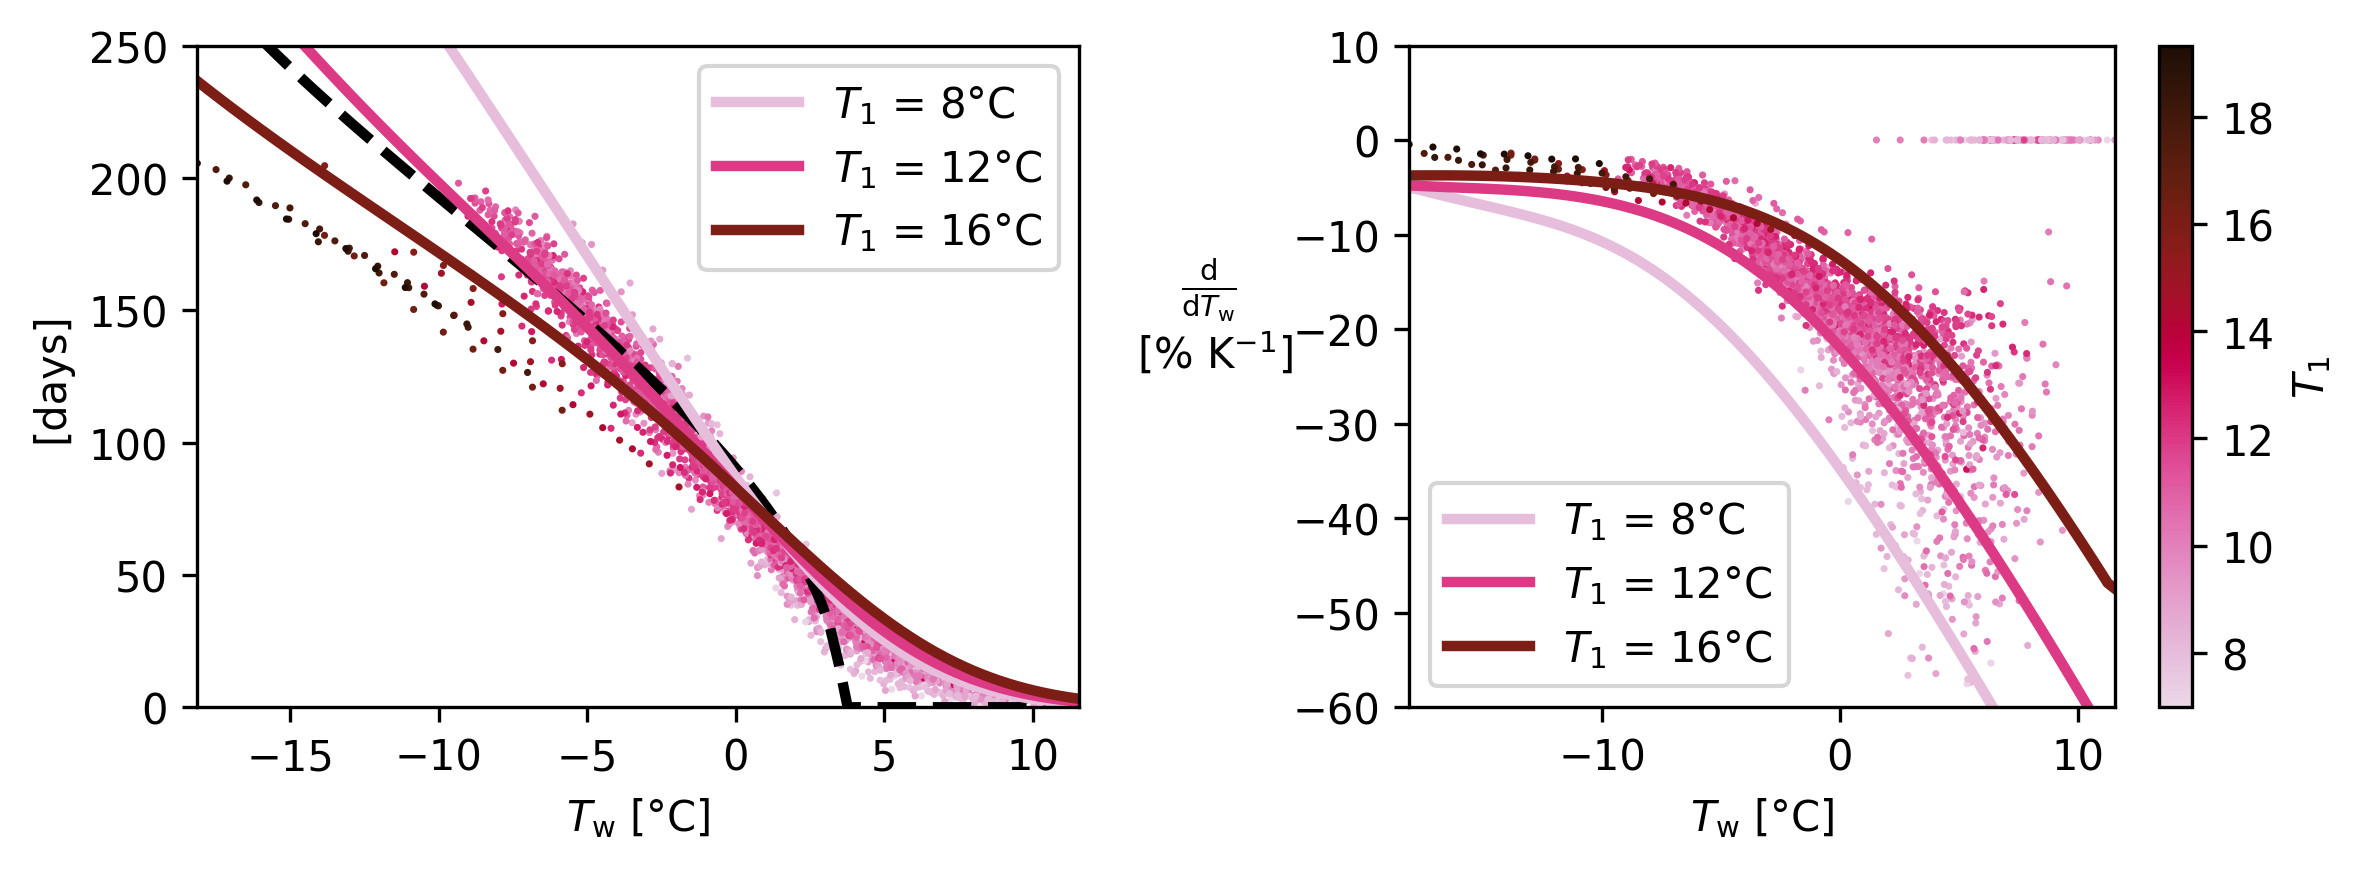

In [74]:
fig = plt.figure(figsize=(8,3),dpi=300)
gs = GridSpec(1, 2)

# colormap selection
normalize = Normalize(vmin=np.min(stationApproxAmpsSin), vmax=np.max(stationApproxAmpsSin))
scalarMap = ScalarMappable(norm=normalize, cmap=cmr.get_sub_cmap('cmr.flamingo_r', 0.1, 0.9))

#### Plot of tau_F ####
ax0 = fig.add_subplot(gs[0])

# add analytic curves
amplitudeRange = [8,12,16]
TwRange = np.linspace(np.min(TwArray),np.max(TwArray),100) 
assumedSigma = 4.5

# determinsitic
omega = 2*np.pi/365
tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,12.5)/12.5)
tauF_0sigma[np.isnan(tauF_0sigma)]=0
ax0.plot(TwRange,tauF_0sigma,linewidth=2.5,
         linestyle='--',c='k')

# noisy
for ja,a in enumerate(amplitudeRange):
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle
    ax0.plot(TwRange,E_tauF_normalDistDaily(a,assumedSigma,T0Range),linewidth=2.5,
             label=r'$T_1$ = ' + f'{a}' + '$\degree$C',c=scalarMap.to_rgba(a))



# add station data
for l,adj in enumerate(Tw_adjs):
    ax0.scatter(TwArray[l],adjTauFList[l],.5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

ax0.set_ylim(0,250);
ax0.set_xlim([np.min(TwRange),np.max(TwRange)])
ax0.set_ylabel('[days]')
ax0.set_xlabel(r'$T_\text{w}$ [$\degree$C]')
ax0.legend()

#### Plot of tau_F sensitivity ####
ax1 = fig.add_subplot(gs[1])

# add analytic curves
for ja,a in enumerate(amplitudeRange):
    analyticDeriv = (np.gradient(np.log(E_tauF_normalDistDaily(a,assumedSigma,T0Range)))/(np.gradient(TwRange)))
    ax1.plot(TwRange,analyticDeriv*100,linewidth=2.5,
             label=r'$T_1$ = ' + f'{a}' + '$\degree$C',c=scalarMap.to_rgba(a)) #r'$T_1$ = ' + f'{a}' + '$\degree$C'

# T0overT1Range_fullDeterm = np.linspace(-.75,2.5,300)
# omega = 2*np.pi/365
# tauF_0sigma = 2/omega * np.arccos(T0overT1Range_fullDeterm)
# analyticDeriv_0sigma = -2/(omega*assumedAmp)*(1/np.sqrt(1-T0overT1Range_fullDeterm**2))/tauF_0sigma
# ax1.plot(T0overT1Range_fullDeterm,analyticDeriv_0sigma*100,linewidth=2.5
#         ,label=r'$\sigma/T_1$ = ' + f'0')
    
# add station data
for l,adj in enumerate(Tw_adjs):
    colorbarPlot = ax1.scatter(TwArray[l],tauFSenList_climToDist[l]*100,.5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

cbar = fig.colorbar(colorbarPlot)
cbar.ax.set_ylabel(r'$T_1$')

ax1.set_ylim([-60,10])
ax1.set_xlim([np.min(TwRange),np.max(TwRange)])

ax1.set_ylabel(r'$\frac{\text{d}}{\text{d}T_\text{w}}$' + '\n [% K$^{-1}$]',rotation=0,labelpad=20)
ax1.set_xlabel(r'$T_\text{w}$ [$\degree$C]')
ax1.legend()

plt.tight_layout()

## For use in final figure

Scatter: $T_w$ on x axis, sensitivity using expected values of $\tau_\text{F}$, colored by amplitude

In [ ]:
fig = plt.figure(figsize=(8,3),dpi=300)
gs = GridSpec(1, 2)

# colormap selection
normalize = Normalize(vmin=np.min(stationApproxAmpsSin), vmax=np.max(stationApproxAmpsSin))
scalarMap = ScalarMappable(norm=normalize, cmap=cmr.get_sub_cmap('cmr.flamingo_r', 0.1, 0.9))

#### Plot of tau_F ####
ax0 = fig.add_subplot(gs[0])

# add analytic curves
amplitudeRange = np.array([8,12,16])
TwRange = np.linspace(np.min(TwArray),np.max(TwArray),100) 

# compute sigma based on best fit between sigma and T1 in obs
sigma_fromBestFit = odrBestFitFunction(amplitudeRange)

# determinsitic
omega = 2*np.pi/365
tauF_0sigma = 2/omega * np.arccos(annualMean_fromTw(TwRange,12.5)/12.5)
tauF_0sigma[np.logical_and(np.isnan(tauF_0sigma),TwRange>-10)]=0
ax0.plot(TwRange,tauF_0sigma,linewidth=2.5,
         linestyle='--',c='k')

# noisy
for ja,a in enumerate(amplitudeRange):
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle
    ax0.plot(TwRange,E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range),linewidth=2.5,
             label=r'$T_1$ = ' + f'{a}' + r'$\degree$C',c=scalarMap.to_rgba(a))

# add station data
for l,adj in enumerate(Tw_adjs):
    ax0.scatter(TwArray[l],adjTauFList[l],5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

ax0.set_ylim(0,250);
ax0.set_xlim([np.min(TwRange),np.max(TwRange)])
ax0.set_ylabel('[days]')
ax0.set_xlabel(r'$T_\text{w}$ [$\degree$C]')
ax0.legend()

#### Plot of tau_F sensitivity ####
ax1 = fig.add_subplot(gs[1])

# add analytic curves
for ja,a in enumerate(amplitudeRange):
    T0Range = annualMean_fromTw(TwRange,a) # assumes cosine seasonal cycle
    analyticDeriv = (np.gradient(np.log(E_tauF_normalDistDaily(a,sigma_fromBestFit[ja],T0Range)))/(np.gradient(TwRange)))
    ax1.plot(TwRange,analyticDeriv*100,linewidth=2.5,
             label=r'$T_1$ = ' + f'{a}' + r'$\degree$C',c=scalarMap.to_rgba(a)) #r'$T_1$ = ' + f'{a}' + '$\degree$C'
    
# add station data
for l,adj in enumerate(Tw_adjs):
    colorbarPlot = ax1.scatter(TwArray[l],tauFSenList_EtauF[l]*100,.5,c=stationApproxAmpsSin,cmap=scalarMap.cmap)

cbar = fig.colorbar(colorbarPlot)
cbar.ax.set_ylabel(r'$T_1$')

ax1.set_ylim([-60,10])
ax1.set_xlim([np.min(TwRange),np.max(TwRange)])

ax1.set_ylabel(r'$\frac{\text{d}\ln x}{\text{d}T_\text{w}}$' + ' [% K$^{-1}$]',rotation=90,labelpad=2)
ax1.set_xlabel(r'$T_\text{w}$ [$\degree$C]')
ax1.legend()

plt.tight_layout()

In [33]:
## This is the data that is going in the final figure. Save it here for plotting.
saveBool = 0
if saveBool:
    pathToSave = '...../figureData'
    np.savez(pathToSave + '/figure7Sen.npz',
             TwArray=TwArray,
             Tw_adjs=Tw_adjs,
             odrBestFitFunction=odrBestFitFunction,
             adjTauFList=adjTauFList,
             tauFSenList_EtauF=tauFSenList_EtauF,
             stationApproxAmpsSin=stationApproxAmpsSin
             )